# Replication of Table 1

This notebook uses monthly factor returns from November 1990 to March 2011.

We will calculate the available parts of Table 1 from Fama and French (2012) and compare Global Developed Markets with Japan.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

In [2]:
DATA_DIR = Path("cleaned_data")

In [3]:
developed_factors = pd.read_csv(
    DATA_DIR / "developed_3_factors.csv",
    parse_dates=["date"]
)

In [4]:
developed_momentum = pd.read_csv(
    DATA_DIR / "developed_momentum.csv",
    parse_dates=["date"]
)

In [5]:
japan_factors = pd.read_csv(
    DATA_DIR / "japan_3_factors.csv",
    parse_dates=["date"]
)

In [6]:
japan_momentum = pd.read_csv(
    DATA_DIR / "japan_momentum.csv",
    parse_dates=["date"]
)

In [7]:
developed = developed_factors.merge(
    developed_momentum,
    on="date",
    validate="one_to_one"
)

In [8]:
japan = japan_factors.merge(
    japan_momentum,
    on="date",
    validate="one_to_one"
)

In [9]:
print("Developed observations:", len(developed))
print("Japan observations:", len(japan))

Developed observations: 245
Japan observations: 245


## Task 1: Global Developed Markets

Use the four factor columns:

- Mkt-RF
- SMB
- HML
- WML

For each factor, calculate:

1. Mean monthly return
2. Standard deviation of monthly returns
3. t-statistic of the mean

Round the final results to two decimal places.

Display the results in a table with the following columns:

- Mean
- Std dev
- t-Mean

In [10]:
FACTORS = ["Mkt-RF", "SMB", "HML", "WML"]


def factor_statistics(data, factors=FACTORS):
    """Mean, standard deviation and t-statistic of the mean for each factor."""
    returns = data[factors]
    n_months = len(returns)

    mean = returns.mean()
    std_dev = returns.std()  # sample standard deviation (divides by n - 1)
    t_mean = mean / (std_dev / np.sqrt(n_months))

    table = pd.DataFrame({
        "Mean": mean,
        "Std dev": std_dev,
        "t-Mean": t_mean,
    })
    return table.round(2)


global_table = factor_statistics(developed)
print("Global Developed Markets:", len(developed), "months")
global_table

Global Developed Markets: 245 months


,Mean,Std dev,t-Mean
Mkt-RF,0.44,4.37,1.57
SMB,0.08,2.20,0.58
HML,0.47,2.51,2.90
WML,0.62,4.25,2.28


## Task 2: Japan

Repeat Task 1 using the Japanese factor returns.

Calculate the mean, standard deviation and t-statistic of the mean for:

- Mkt-RF
- SMB
- HML
- WML

Round the final results to two decimal places.

In [11]:
japan_table = factor_statistics(japan)
print("Japan:", len(japan), "months")
japan_table

Japan: 245 months


,Mean,Std dev,t-Mean
Mkt-RF,-0.12,6.04,-0.31
SMB,-0.09,3.52,-0.41
HML,0.49,2.99,2.58
WML,0.08,4.76,0.27


## Task 3: Compare the Results with the Paper

Compare your results with the Global and Japan sections of Table 1 in Fama and French (2012).

1. Are your results close to the values reported in the paper? Note any important differences.
2. Compare the four factor returns for Global Developed Markets and Japan. Identify and interpret the main results you would report.
3. Based on the means and t-statistics, which factor premiums appear meaningful?

Note your findings in your report

## Task 4: Plot the Factor Returns

Create a figure with eight panels arranged in four rows and two columns.

Each row should represent one factor:

1. Mkt-RF
2. SMB
3. HML
4. WML

The left column should show Global Developed Markets.

The right column should show Japan.

Each panel should include:

- Dates on the horizontal axis
- Monthly factor values on the vertical axis
- A title showing the market and factor

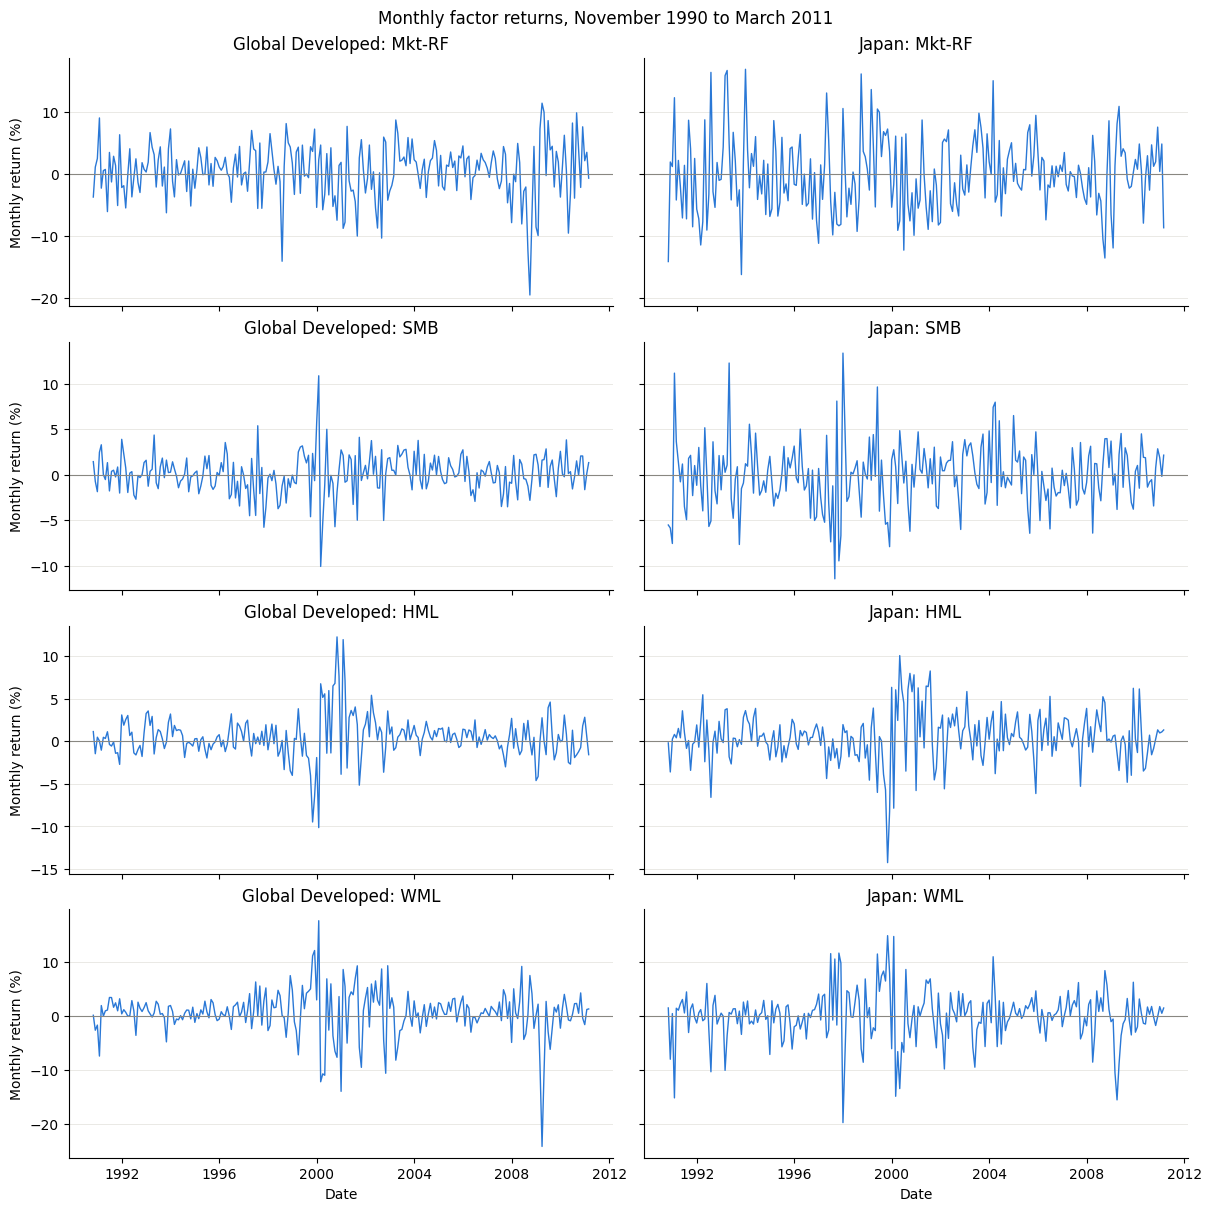

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

LINE_COLOR = "#2a78d6"
ZERO_LINE_COLOR = "#898781"
GRID_COLOR = "#e6e5e1"

markets = [("Global Developed", developed), ("Japan", japan)]

# Rows: one per factor. Columns: Global on the left, Japan on the right.
# sharey="row" puts Global and Japan on the same scale for each factor.
fig, axes = plt.subplots(
    nrows=len(FACTORS),
    ncols=len(markets),
    figsize=(12, 12),
    sharex=True,
    sharey="row",
    layout="constrained",
)

for row, factor in enumerate(FACTORS):
    for col, (market_name, data) in enumerate(markets):
        ax = axes[row, col]
        ax.plot(data["date"], data[factor], color=LINE_COLOR, linewidth=1)
        ax.axhline(0, color=ZERO_LINE_COLOR, linewidth=0.8)
        ax.set_title(f"{market_name}: {factor}")
        ax.grid(axis="y", color=GRID_COLOR, linewidth=0.6)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)
        if col == 0:
            ax.set_ylabel("Monthly return (%)")

for ax in axes[-1]:
    ax.set_xlabel("Date")
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("Monthly factor returns, November 1990 to March 2011")
plt.show()

## Task 5: Interpret the Graphs

Study the factor-return graphs for Global Developed Markets and Japan.

1. Identify the most important patterns, unusual periods or differences between the two markets.
2. Explain what these patterns mean in terms of market, size, value and momentum performance.
3. Briefly state whether the graphs support the conclusions you reached from Table 1.

Note your findings in your report